# Rolling Window IC 비교 실험

## 실험 목적
- Rolling window 크기(120 / 150 / 180일)에 따른 IC 변화 측정
- Ablation 3그룹: OHLCV / OHLCV+외생변수 / OHLCV+news Dual-Source
- 커뮤니티 관련 피처 완전 제외

## 데이터
- 실제 KIS 1분봉 parquet (`artifacts/data/{ticker}/bars_1m_*.parquet`)
- ECOS 외생변수 (interest_rate, usd_krw)
- Naver 뉴스 기반 Dual-Source (news_score, news_count)

## label
- `label_5m_ret`: 5분 후 수익률 (cross-sectional rank 기준 IC 측정)

---
## 0. 경로 설정 및 라이브러리

In [ ]:
import warnings
warnings.filterwarnings('ignore')

import sys
import json
from pathlib import Path
from datetime import datetime, timedelta

import numpy as np
import pandas as pd
from scipy import stats
import lightgbm as lgb
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# ── AI 루트 자동 탐지 (노트북 위치 기준) ──────────────────────────────

NB_DIR   = Path().resolve()

AI_ROOT  = next((p for p in [NB_DIR, *NB_DIR.parents] if (p / 'CLAUDE.md').exists()), NB_DIR)
DATA_DIR = AI_ROOT / 'artifacts' / 'data'

sys.path.insert(0, str(AI_ROOT))

print(f'AI_ROOT  : {AI_ROOT}')
print(f'DATA_DIR : {DATA_DIR}')
print(f'DATA_DIR exists: {DATA_DIR.exists()}')

---
## 1. 유니버스 및 실험 설정

In [ ]:
import yaml

# ── 유니버스 (sector_config.yaml 기준 30) ──────────────────────
sector_cfg_path = AI_ROOT / 'new' / 'config' / 'sector_config.yaml'
if sector_cfg_path.exists():
    with open(sector_cfg_path, encoding='utf-8') as f:
        sector_cfg = yaml.safe_load(f)
    UNIVERSE = [
    str(t).zfill(6)
    for t in sector_cfg.get('ticker_to_sector', {}).keys()
    ]
    
    print(f'유니버스 로드 완료: {len(UNIVERSE)}종목')
else:
    # fallback: artifacts/data 폴더에 있는 종목 전부
    UNIVERSE = sorted([d.name for d in DATA_DIR.iterdir() if d.is_dir()])
    print(f'sector_config 없음 → data 폴더 기준: {len(UNIVERSE)}종목')

print('종목:', UNIVERSE)

# ── 실험 파라미터 ─────────────────────────────────────────────────────
WINDOWS   = [120, 150, 180]   # rolling window (거래일 기준)
LABEL_COL = 'label_5m_ret'    # IC 측정 대상 label
N_FOLDS   = 5                 # walk-forward 분할 수
SEED      = 42

# ── Ablation 그룹 정의 ────────────────────────────────────────────────
#   community 관련 피처는 완전 제외
GROUPS = {
    'OHLCV':              None,   # 아래에서 동적으로 채움
    'OHLCV+Exog':         None,
    'OHLCV+News_DS':      None,
}

print('\n실험 설정:')
print(f'  Rolling windows : {WINDOWS}일')
print(f'  Walk-forward    : {N_FOLDS}폴드')
print(f'  Label           : {LABEL_COL}')
print(f'  Ablation 그룹   : {list(GROUPS.keys())}')

유니버스 로드 완료: 30종목
종목: ['005930', '000660', '042700', '403870', '058470', '329180', '042660', '010140', '009540', '267250', '006400', '051910', '373220', '096770', '247540', '012450', '047810', '079550', '298040', '272210', '105560', '055550', '086790', '024110', '000810', '005380', '000270', '012330', '011210', '086280']

실험 설정:
  Rolling windows : [120, 150, 180]일
  Walk-forward    : 5폴드
  Label           : label_5m_ret
  Ablation 그룹   : ['OHLCV', 'OHLCV+Exog', 'OHLCV+News_DS']


---
## 2. Parquet 로드

In [39]:
def load_bars(ticker: str) -> pd.DataFrame:
    """ticker의 전체 parquet 파일 합쳐서 반환."""
    ticker_dir = DATA_DIR / ticker
    files = sorted(ticker_dir.glob('bars_1m_*.parquet'))
    if not files:
        return pd.DataFrame()
    df = pd.concat([pd.read_parquet(f) for f in files], ignore_index=True)
    # timestamp 컬럼 정규화
    ts_col = next((c for c in df.columns if 'time' in c.lower() or 'ts' in c.lower()), None)
    if ts_col and ts_col != 'ts':
        df = df.rename(columns={ts_col: 'ts'})
    if 'ts' in df.columns:
        df['ts'] = pd.to_datetime(df['ts'])
        df = df.sort_values('ts').reset_index(drop=True)
    df['ticker'] = ticker
    return df

# 전체 로드
raw_frames = {}
for tk in UNIVERSE:
    df = load_bars(tk)
    if not df.empty:
        raw_frames[tk] = df
        print(f'  {tk}: {len(df):,}행  ({df["ts"].min().date()} ~ {df["ts"].max().date()})')
    else:
        print(f'  {tk}: 파일 없음 → 스킵')

print(f'\n로드 완료: {len(raw_frames)}/{len(UNIVERSE)} 종목')

  005930: 94,317행  (2025-05-12 ~ 2026-05-18)
  000660: 94,689행  (2025-05-12 ~ 2026-05-18)
  042700: 94,656행  (2025-05-12 ~ 2026-05-18)
  403870: 94,545행  (2025-05-12 ~ 2026-05-18)
  058470: 94,708행  (2025-05-12 ~ 2026-05-18)
  329180: 94,694행  (2025-05-12 ~ 2026-05-18)
  042660: 94,689행  (2025-05-12 ~ 2026-05-18)
  010140: 94,692행  (2025-05-12 ~ 2026-05-18)
  009540: 94,699행  (2025-05-12 ~ 2026-05-18)
  267250: 94,680행  (2025-05-12 ~ 2026-05-18)
  006400: 94,685행  (2025-05-12 ~ 2026-05-18)
  051910: 94,689행  (2025-05-12 ~ 2026-05-18)
  373220: 94,695행  (2025-05-12 ~ 2026-05-18)
  096770: 94,686행  (2025-05-12 ~ 2026-05-18)
  247540: 94,705행  (2025-05-12 ~ 2026-05-18)
  012450: 94,681행  (2025-05-12 ~ 2026-05-18)
  047810: 94,690행  (2025-05-12 ~ 2026-05-18)
  079550: 94,656행  (2025-05-12 ~ 2026-05-18)
  298040: 94,680행  (2025-05-12 ~ 2026-05-18)
  272210: 94,659행  (2025-05-12 ~ 2026-05-18)
  105560: 94,695행  (2025-05-12 ~ 2026-05-18)
  055550: 94,699행  (2025-05-12 ~ 2026-05-18)
  086790: 

---
## 3. 피처 엔지니어링

In [40]:
def compute_ohlcv_features(df: pd.DataFrame) -> pd.DataFrame:
    """
    OHLCV 파생 피처 (커뮤니티 없음).
    dataset_builder._compute_rolling_features 수식 기준.
    """
    c = df['close'].astype(float)
    v = df['volume'].astype(float)
    h = df['high'].astype(float)
    lo = df['low'].astype(float)

    # ── 기존 4개 ──────────────────────────────────────────────────────
    roll30 = c.rolling(30)
    df['feat_1m_close_robust_z'] = (c - roll30.median()) / (roll30.quantile(0.75) - roll30.quantile(0.25) + 1e-9)
    df['feat_5m_ret']            = c.pct_change(5)
    df['feat_30m_vol']           = v.rolling(30).std() / (v.rolling(30).mean() + 1e-9)
    df['feat_60m_trend']         = c.rolling(60).apply(lambda x: np.polyfit(np.arange(len(x)), x, 1)[0] / (x.mean() + 1e-9) if len(x) == 60 else np.nan, raw=True)

    # ── 추가 OHLCV 파생 ───────────────────────────────────────────────
    df['feat_volume_ratio']      = v / (v.rolling(20).mean() + 1e-9)
    df['feat_price_range']       = (h - lo) / (c + 1e-9)
    df['feat_10m_ret']           = c.pct_change(10)
    # VWAP 이탈도
    typical = (h + lo + c) / 3
    vwap    = (typical * v).rolling(30).sum() / (v.rolling(30).sum() + 1e-9)
    df['feat_vwap_dev']          = (c - vwap) / (vwap + 1e-9)

    return df


def compute_exog_features(df: pd.DataFrame, exog: pd.DataFrame) -> pd.DataFrame:
    if exog.empty:
        for col in ['feat_interest_rate', 'feat_usd_krw', 'feat_us_vix',
                     'feat_us_sp500_change', 'feat_us_nasdaq_change', 'feat_us_soxx_change',
                     'feat_foreign_net_buy', 'feat_institutional_net_buy']:
            df[col] = np.nan
        return df
    df['_date']   = df['ts'].dt.date.astype(str)
    df['_ticker'] = df['ticker']
    exog['_date']   = exog['date'].astype(str)
    exog['_ticker'] = exog['ticker'].astype(str).str.zfill(6)
    merge_cols = ['interest_rate', 'usd_krw', 'us_sp500_change', 'us_nasdaq_change',
                  'us_vix', 'us_soxx_change', 'foreign_net_buy', 'institutional_net_buy']
    df = df.merge(exog[['_ticker', '_date'] + merge_cols], on=['_ticker', '_date'], how='left')
    rename = {col: f'feat_{col}' for col in merge_cols}
    df = df.rename(columns=rename)
    df = df.drop(columns=['_date', '_ticker'], errors='ignore')
    return df


def compute_news_ds_features(df: pd.DataFrame, news_daily: pd.DataFrame) -> pd.DataFrame:
    if news_daily.empty:
        df['feat_news_score'] = 0.0
        df['feat_news_momentum'] = 0.0
        return df
    df['_date']   = df['ts'].dt.date.astype(str)
    df['_ticker'] = df['ticker']
    news_daily['_date']   = news_daily['date'].astype(str)
    news_daily['_ticker'] = news_daily['ticker'].astype(str).str.zfill(6)
    df = df.merge(
        news_daily[['_ticker', '_date', 'news_score']],
        on=['_ticker', '_date'], how='left'
    ).fillna({'news_score': 0.0})
    df['feat_news_score']    = df['news_score']
    df = df.sort_values('ts')
    df['feat_news_momentum'] = df.groupby('ticker')['feat_news_score'].transform(
        lambda x: x.rolling(3 * 390, min_periods=1).mean()
    )
    df = df.drop(columns=['_date', '_ticker', 'news_score'], errors='ignore')
    return df


def make_label(df: pd.DataFrame, horizon: int = 5) -> pd.DataFrame:
    """5분 후 수익률 label (PIT-safe: shift(-horizon))."""
    df[LABEL_COL] = df['close'].astype(float).pct_change(horizon).shift(-horizon)
    return df


print('피처 함수 정의 완료')

피처 함수 정의 완료


---
## 4. 외생변수 및 뉴스 데이터 로드

In [41]:
import json

# 외생변수
exog_path = AI_ROOT / 'artifacts' / 'exogenous'
if exog_path.exists():
    records = []
    for f in sorted(exog_path.glob('*.json')):
        with open(f, encoding='utf-8') as fp:
            data = json.load(fp)
        date = data.get('batch_date', '')
        feat = data.get('features', {})
        base = {
            'date':              date,
            'interest_rate':     feat.get('interest_rate', None),
            'usd_krw':           feat.get('usd_krw', None),
            'us_sp500_change':   feat.get('us_sp500_change', None),
            'us_nasdaq_change':  feat.get('us_nasdaq_change', None),
            'us_vix':            feat.get('us_vix', None),
            'us_soxx_change':    feat.get('us_soxx_change', None),
        }
        for ticker, inv in data.get('per_ticker', {}).items():
            row = base.copy()
            row['ticker']                = str(ticker).zfill(6)
            row['foreign_net_buy']       = inv.get('foreign_net_buy', None)
            row['institutional_net_buy'] = inv.get('institutional_net_buy', None)
            records.append(row)
    exog_df = pd.DataFrame(records)
    print(f'외생변수 로드: {len(exog_df)}행  컬럼={list(exog_df.columns)}')
else:
    exog_df = pd.DataFrame()
    print('외생변수 파일 없음')

# 뉴스 DS (커뮤니티 완전 제외 — news_score_t만 사용)
news_path = AI_ROOT / 'artifacts' / 'dual_source'
if news_path.exists():
    records = []
    for f in sorted(news_path.glob('*.json')):
        with open(f, encoding='utf-8') as fp:
            data = json.load(fp)
        date = data.get('batch_date', '')
        for s in data.get('scores', []):
            records.append({
                'date':       date,
                'ticker':     str(s['ticker']).zfill(6),
                'news_score': s.get('news_score_t', 0.0),
            })
    news_df = pd.DataFrame(records)
    print(f'뉴스 DS 로드: {len(news_df)}행  컬럼={list(news_df.columns)}')
else:
    news_df = pd.DataFrame()
    print('뉴스 DS 파일 없음')

외생변수 로드: 7500행  컬럼=['date', 'interest_rate', 'usd_krw', 'us_sp500_change', 'us_nasdaq_change', 'us_vix', 'us_soxx_change', 'ticker', 'foreign_net_buy', 'institutional_net_buy']
뉴스 DS 로드: 7500행  컬럼=['date', 'ticker', 'news_score']


---
## 5. 전체 피처 DataFrame 구축

In [45]:
all_frames = []

for tk, df in raw_frames.items():
    df = df.copy()
    df = compute_ohlcv_features(df)
    df = compute_exog_features(df, exog_df)
    df = compute_news_ds_features(df, news_df)
    df = make_label(df)
    all_frames.append(df)

FULL_DF = pd.concat(all_frames, ignore_index=True)
FULL_DF = FULL_DF.dropna(subset=[LABEL_COL])

print(f'전체 DataFrame: {FULL_DF.shape}')
print(f'기간: {FULL_DF["ts"].min().date()} ~ {FULL_DF["ts"].max().date()}')

# ── 피처 그룹 확정 ────────────────────────────────────────────────────
OHLCV_FEATS   = [c for c in FULL_DF.columns if c.startswith('feat_') and
                 not any(x in c for x in ['interest', 'usd', 'us_', 'foreign', 'institutional', 'news'])]
EXOG_FEATS    = [c for c in FULL_DF.columns if c.startswith('feat_') and
                 any(x in c for x in ['interest', 'usd', 'us_', 'foreign', 'institutional'])]
NEWS_DS_FEATS = [c for c in FULL_DF.columns if c.startswith('feat_news')]

GROUPS = {
    'OHLCV':         OHLCV_FEATS,
    'OHLCV+Exog':    OHLCV_FEATS + EXOG_FEATS,
    'OHLCV+News_DS': OHLCV_FEATS + NEWS_DS_FEATS,
}

print('\n피처 그룹:')
for g, feats in GROUPS.items():
    print(f'  {g:<20}: {feats}')

전체 DataFrame: (2838255, 32)
기간: 2025-05-12 ~ 2026-05-18

피처 그룹:
  OHLCV               : ['feat_1m_close_robust_z', 'feat_5m_ret', 'feat_30m_vol', 'feat_60m_trend', 'feat_volume_ratio', 'feat_price_range', 'feat_10m_ret', 'feat_vwap_dev']
  OHLCV+Exog          : ['feat_1m_close_robust_z', 'feat_5m_ret', 'feat_30m_vol', 'feat_60m_trend', 'feat_volume_ratio', 'feat_price_range', 'feat_10m_ret', 'feat_vwap_dev', 'feat_interest_rate', 'feat_usd_krw', 'feat_us_sp500_change', 'feat_us_nasdaq_change', 'feat_us_vix', 'feat_us_soxx_change', 'feat_foreign_net_buy', 'feat_institutional_net_buy']
  OHLCV+News_DS       : ['feat_1m_close_robust_z', 'feat_5m_ret', 'feat_30m_vol', 'feat_60m_trend', 'feat_volume_ratio', 'feat_price_range', 'feat_10m_ret', 'feat_vwap_dev', 'feat_news_score', 'feat_news_momentum']


---
## 6. IC 측정 유틸리티

In [46]:
def rank_ic(y_pred: np.ndarray, y_true: np.ndarray) -> float:
    """Spearman (rank) IC."""
    mask = ~(np.isnan(y_pred) | np.isnan(y_true))
    if mask.sum() < 10:
        return np.nan
    return float(stats.spearmanr(y_pred[mask], y_true[mask]).statistic)


def walk_forward_ic(
    df: pd.DataFrame,
    feature_cols: list,
    window_days: int,
    n_folds: int = 5,
    seed: int = 42,
) -> dict:
    """
    Walk-forward 방식으로 IC 측정.
    window_days: rolling train window 크기 (거래일 기준, 1일=390분봉).
    """
    BARS_PER_DAY = 390
    window_bars  = window_days * BARS_PER_DAY

    df = df.sort_values('ts').reset_index(drop=True)
    total = len(df)

    # fold 분할: 전체를 n_folds+1 구간으로 나눔
    fold_size = total // (n_folds + 1)
    ic_list   = []

    lgb_params = dict(
        objective='regression',
        n_estimators=200,
        learning_rate=0.05,
        num_leaves=31,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=seed,
        verbose=-1,
    )

    for fold in range(n_folds):
        test_start = (fold + 1) * fold_size
        test_end   = test_start + fold_size
        train_start = max(0, test_start - window_bars)
        train_end   = test_start

        train_df = df.iloc[train_start:train_end]
        test_df  = df.iloc[test_start:min(test_end, total)]

        valid_feats = [f for f in feature_cols if f in df.columns]
        if not valid_feats or train_df.empty or test_df.empty:
            continue

        X_train = train_df[valid_feats].replace([np.inf, -np.inf], np.nan).fillna(0)
        y_train = train_df[LABEL_COL].fillna(0)
        X_test  = test_df[valid_feats].replace([np.inf, -np.inf], np.nan).fillna(0)
        y_test  = test_df[LABEL_COL].values

        model = lgb.LGBMRegressor(**lgb_params)
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        ic = rank_ic(y_pred, y_test)
        ic_list.append(ic)

    ic_arr = np.array([x for x in ic_list if not np.isnan(x)])
    return {
        'mean_ic':   float(np.mean(ic_arr))   if len(ic_arr) else np.nan,
        'std_ic':    float(np.std(ic_arr))    if len(ic_arr) else np.nan,
        'ir':        float(np.mean(ic_arr) / (np.std(ic_arr) + 1e-9)) if len(ic_arr) else np.nan,
        'ic_list':   ic_list,
        'n_valid':   len(ic_arr),
    }


print('IC 유틸리티 정의 완료')

IC 유틸리티 정의 완료


---
## 7. 메인 실험: Window × Ablation 그리드

In [47]:
results = {}  # (window, group) → dict

for window in WINDOWS:
    for group_name, feats in GROUPS.items():
        key = (window, group_name)
        print(f'\n[실험] window={window}일  group={group_name}  피처수={len(feats)}')
        res = walk_forward_ic(FULL_DF, feats, window_days=window, n_folds=N_FOLDS, seed=SEED)
        results[key] = res
        print(f'  → mean IC={res["mean_ic"]:+.4f}  std={res["std_ic"]:.4f}  IR={res["ir"]:+.3f}  (n={res["n_valid"]})')

print('\n\n=== 실험 완료 ===')


[실험] window=120일  group=OHLCV  피처수=8
  → mean IC=+0.0737  std=0.0281  IR=+2.628  (n=5)

[실험] window=120일  group=OHLCV+Exog  피처수=16
  → mean IC=+0.0644  std=0.0309  IR=+2.085  (n=5)

[실험] window=120일  group=OHLCV+News_DS  피처수=10
  → mean IC=+0.0550  std=0.0212  IR=+2.592  (n=5)

[실험] window=150일  group=OHLCV  피처수=8
  → mean IC=+0.0722  std=0.0304  IR=+2.374  (n=5)

[실험] window=150일  group=OHLCV+Exog  피처수=16
  → mean IC=+0.0690  std=0.0317  IR=+2.181  (n=5)

[실험] window=150일  group=OHLCV+News_DS  피처수=10
  → mean IC=+0.0534  std=0.0256  IR=+2.083  (n=5)

[실험] window=180일  group=OHLCV  피처수=8
  → mean IC=+0.0731  std=0.0339  IR=+2.159  (n=5)

[실험] window=180일  group=OHLCV+Exog  피처수=16
  → mean IC=+0.0699  std=0.0322  IR=+2.171  (n=5)

[실험] window=180일  group=OHLCV+News_DS  피처수=10
  → mean IC=+0.0564  std=0.0263  IR=+2.142  (n=5)


=== 실험 완료 ===


---
## 8. 결과 테이블

In [48]:
rows = []
for (window, group), res in results.items():
    rows.append({
        'Window(일)':  window,
        'Ablation':    group,
        '피처 수':     len(GROUPS[group]),
        'Mean IC':     round(res['mean_ic'], 4),
        'Std IC':      round(res['std_ic'],  4),
        'IC-IR':       round(res['ir'],      3),
        'Valid Folds': res['n_valid'],
    })

result_df = pd.DataFrame(rows)
result_df = result_df.sort_values(['Window(일)', 'Ablation']).reset_index(drop=True)

# IC 기준선 표시
IC_THRESHOLD = 0.02
def highlight_ic(val):
    if isinstance(val, float):
        if abs(val) >= IC_THRESHOLD:
            return 'background-color: #d4edda; font-weight: bold'
        elif val < 0:
            return 'background-color: #f8d7da'
    return ''

display(result_df.style.applymap(highlight_ic, subset=['Mean IC']))

print(f'\n※ |IC| >= {IC_THRESHOLD} (risk_config 기준) → 초록 / IC < 0 → 빨강')

,Window(일),Ablation,피처 수,Mean IC,Std IC,IC-IR,Valid Folds
0,120,OHLCV,8,0.073700,0.028100,2.628000,5
1,120,OHLCV+Exog,16,0.064400,0.030900,2.085000,5
2,120,OHLCV+News_DS,10,0.055000,0.021200,2.592000,5
3,150,OHLCV,8,0.072200,0.030400,2.374000,5
4,150,OHLCV+Exog,16,0.069000,0.031700,2.181000,5
5,150,OHLCV+News_DS,10,0.053400,0.025600,2.083000,5
6,180,OHLCV,8,0.073100,0.033900,2.159000,5
7,180,OHLCV+Exog,16,0.069900,0.032200,2.171000,5
8,180,OHLCV+News_DS,10,0.056400,0.026300,2.142000,5



※ |IC| >= 0.02 (risk_config 기준) → 초록 / IC < 0 → 빨강


---
## 9. 시각화 — Window별 IC 비교

In [50]:
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

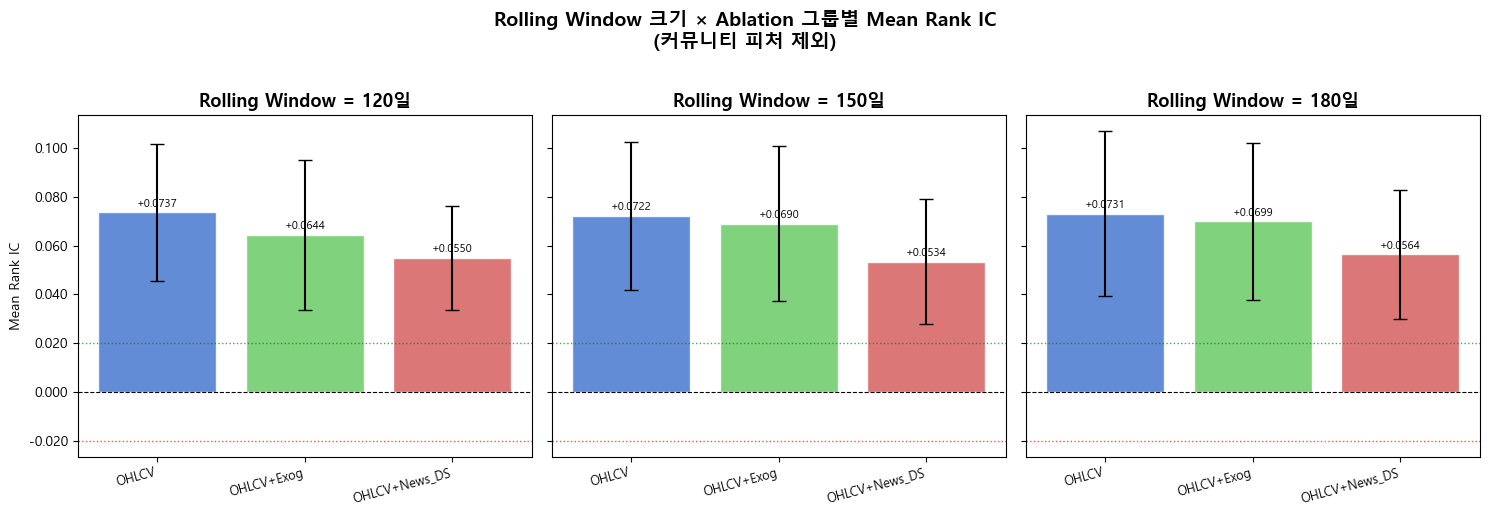

그래프 저장: artifacts/ic_window_ablation.png


In [51]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)
colors = {'OHLCV': '#4878CF', 'OHLCV+Exog': '#6ACC65', 'OHLCV+News_DS': '#D65F5F'}

for ax, window in zip(axes, WINDOWS):
    group_names = list(GROUPS.keys())
    means = [results[(window, g)]['mean_ic'] for g in group_names]
    stds  = [results[(window, g)]['std_ic']  for g in group_names]
    bar_colors = [colors[g] for g in group_names]

    bars = ax.bar(group_names, means, yerr=stds, capsize=5,
                  color=bar_colors, alpha=0.85, edgecolor='white')
    ax.axhline(0,  color='black', linewidth=0.8, linestyle='--')
    ax.axhline( IC_THRESHOLD, color='green', linewidth=1, linestyle=':', alpha=0.7)
    ax.axhline(-IC_THRESHOLD, color='red',   linewidth=1, linestyle=':', alpha=0.7)

    ax.set_title(f'Rolling Window = {window}일', fontsize=13, fontweight='bold')
    ax.set_ylabel('Mean Rank IC' if ax == axes[0] else '')
    ax.set_xticklabels(group_names, rotation=15, ha='right', fontsize=9)
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.3f'))

    for bar, val in zip(bars, means):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.001,
                f'{val:+.4f}', ha='center', va='bottom', fontsize=8)

fig.suptitle('Rolling Window 크기 × Ablation 그룹별 Mean Rank IC\n(커뮤니티 피처 제외)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(AI_ROOT / 'artifacts' / 'ic_window_ablation.png', dpi=150, bbox_inches='tight')
plt.show()
print('그래프 저장: artifacts/ic_window_ablation.png')

---
## 10. 시각화 — Fold별 IC 추이 (최적 window)

최적 window: 120일


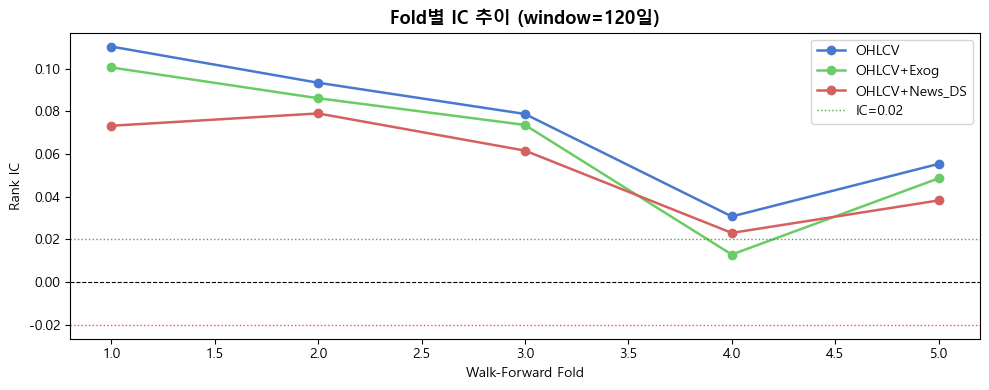

In [52]:
# 최적 window: OHLCV 그룹에서 mean_ic 가장 높은 window
best_window = max(WINDOWS, key=lambda w: results[(w, 'OHLCV')]['mean_ic'])
print(f'최적 window: {best_window}일')

fig, ax = plt.subplots(figsize=(10, 4))
for group_name, color in colors.items():
    ic_list = results[(best_window, group_name)]['ic_list']
    ax.plot(range(1, len(ic_list)+1), ic_list, marker='o', label=group_name,
            color=color, linewidth=1.8, markersize=6)

ax.axhline(0,  color='black', linewidth=0.8, linestyle='--')
ax.axhline( IC_THRESHOLD, color='green', linewidth=1, linestyle=':', alpha=0.7, label=f'IC={IC_THRESHOLD}')
ax.axhline(-IC_THRESHOLD, color='red',   linewidth=1, linestyle=':', alpha=0.7)
ax.set_xlabel('Walk-Forward Fold')
ax.set_ylabel('Rank IC')
ax.set_title(f'Fold별 IC 추이 (window={best_window}일)', fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig(AI_ROOT / 'artifacts' / f'ic_fold_trend_w{best_window}.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 11. 피처 중요도 (최적 window + 전체 그룹)

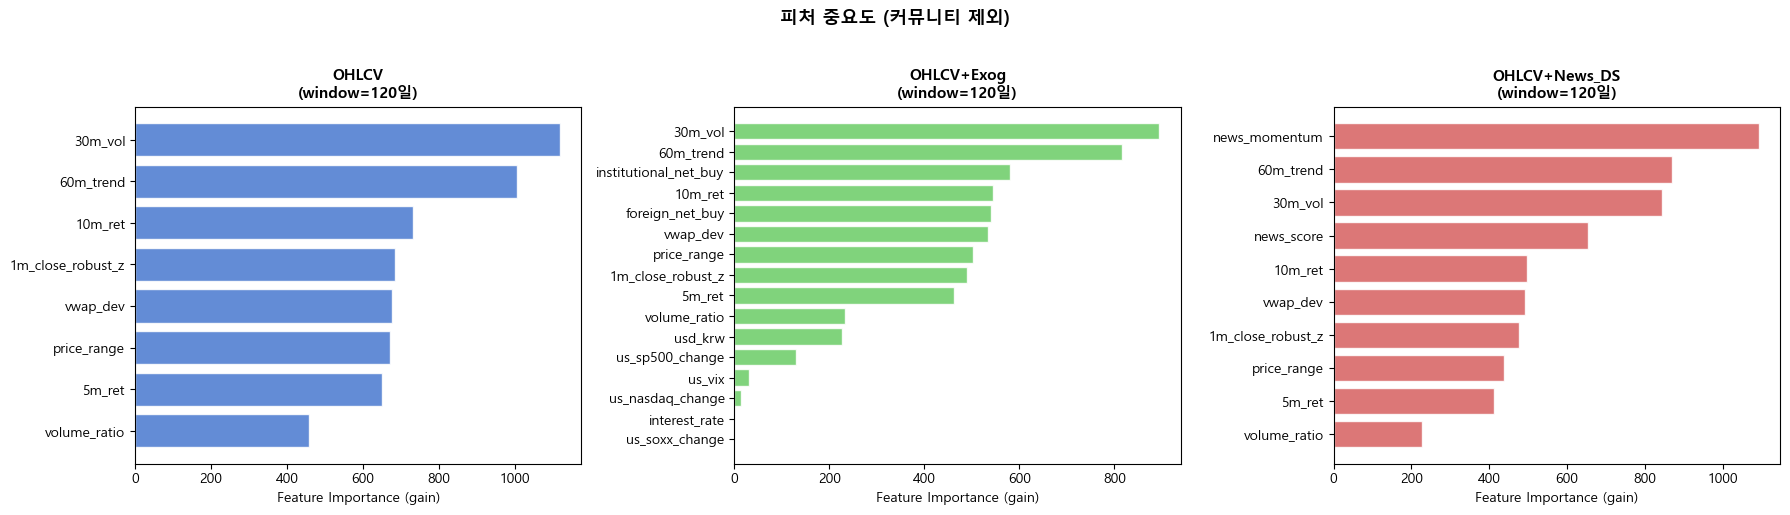

In [53]:
def get_feature_importance(df, feature_cols, window_days, seed=42):
    BARS_PER_DAY = 390
    window_bars  = window_days * BARS_PER_DAY
    train_df = df.sort_values('ts').tail(window_bars)
    valid_feats = [f for f in feature_cols if f in df.columns]
    X = train_df[valid_feats].replace([np.inf, -np.inf], np.nan).fillna(0)
    y = train_df[LABEL_COL].fillna(0)
    model = lgb.LGBMRegressor(n_estimators=200, learning_rate=0.05,
                               num_leaves=31, random_state=seed, verbose=-1)
    model.fit(X, y)
    return dict(zip(valid_feats, model.feature_importances_))


fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (group_name, feats) in zip(axes, GROUPS.items()):
    imp = get_feature_importance(FULL_DF, feats, best_window)
    imp_sorted = dict(sorted(imp.items(), key=lambda x: x[1], reverse=True))
    names = [k.replace('feat_', '') for k in imp_sorted.keys()]
    vals  = list(imp_sorted.values())
    ax.barh(names, vals, color=colors[group_name], alpha=0.85, edgecolor='white')
    ax.set_title(f'{group_name}\n(window={best_window}일)', fontsize=11, fontweight='bold')
    ax.invert_yaxis()
    ax.set_xlabel('Feature Importance (gain)')

plt.suptitle('피처 중요도 (커뮤니티 제외)', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(AI_ROOT / 'artifacts' / f'feature_importance_w{best_window}.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 12. 결과 저장 및 요약

In [54]:
# JSON 저장
out_dir = AI_ROOT / 'artifacts'
out_dir.mkdir(parents=True, exist_ok=True)

save_data = {
    'experiment': 'rolling_window_ic_ablation',
    'timestamp':  datetime.now().isoformat(),
    'config': {
        'windows':         WINDOWS,
        'n_folds':         N_FOLDS,
        'label':           LABEL_COL,
        'ic_threshold':    IC_THRESHOLD,
        'community_feats': 'excluded',
    },
    'feature_groups': {g: feats for g, feats in GROUPS.items()},
    'results': {
        f'w{w}_{g}': {
            'mean_ic':   res['mean_ic'],
            'std_ic':    res['std_ic'],
            'ir':        res['ir'],
            'ic_list':   res['ic_list'],
            'n_valid':   res['n_valid'],
        }
        for (w, g), res in results.items()
    },
    'best_window': best_window,
}

out_path = out_dir / 'rolling_window_ic_results.json'
with open(out_path, 'w', encoding='utf-8') as f:
    json.dump(save_data, f, ensure_ascii=False, indent=2)
print(f'결과 저장: {out_path}')

# ── 최종 요약 출력 ────────────────────────────────────────────────────
print('\n' + '='*70)
print('Rolling Window IC 실험 최종 요약')
print('='*70)
print(f'  데이터    : 실제 KIS parquet  ({len(raw_frames)}종목)')
print(f'  기간      : {FULL_DF["ts"].min().date()} ~ {FULL_DF["ts"].max().date()}')
print(f'  Label     : {LABEL_COL}')
print(f'  커뮤니티  : 완전 제외')
print()
print(f'{"Window":>8} | {"Ablation":<20} | {"Mean IC":>8} | {"Std IC":>7} | {"IC-IR":>6}')
print('-'*60)
for (w, g), res in sorted(results.items()):
    flag = ' ✓' if abs(res['mean_ic']) >= IC_THRESHOLD else ''
    print(f'{w:>8}일 | {g:<20} | {res["mean_ic"]:>+8.4f} | {res["std_ic"]:>7.4f} | {res["ir"]:>+6.3f}{flag}')
print()
print(f'최적 window: {best_window}일  (OHLCV 그룹 기준 mean IC 최대)')
print(f'IC 기준선   : |IC| >= {IC_THRESHOLD} (risk_config.yaml ic_significance_threshold)')

결과 저장: C:\Users\ygjun\OneDrive\바탕 화면\종설_실험\AI\artifacts\rolling_window_ic_results.json

Rolling Window IC 실험 최종 요약
  데이터    : 실제 KIS parquet  (30종목)
  기간      : 2025-05-12 ~ 2026-05-18
  Label     : label_5m_ret
  커뮤니티  : 완전 제외

  Window | Ablation             |  Mean IC |  Std IC |  IC-IR
------------------------------------------------------------
     120일 | OHLCV                |  +0.0737 |  0.0281 | +2.628 ✓
     120일 | OHLCV+Exog           |  +0.0644 |  0.0309 | +2.085 ✓
     120일 | OHLCV+News_DS        |  +0.0550 |  0.0212 | +2.592 ✓
     150일 | OHLCV                |  +0.0722 |  0.0304 | +2.374 ✓
     150일 | OHLCV+Exog           |  +0.0690 |  0.0317 | +2.181 ✓
     150일 | OHLCV+News_DS        |  +0.0534 |  0.0256 | +2.083 ✓
     180일 | OHLCV                |  +0.0731 |  0.0339 | +2.159 ✓
     180일 | OHLCV+Exog           |  +0.0699 |  0.0322 | +2.171 ✓
     180일 | OHLCV+News_DS        |  +0.0564 |  0.0263 | +2.142 ✓

최적 window: 120일  (OHLCV 그룹 기준 mean IC 최대)
IC 기준선   : |IC| >= 0